/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_2087/3154987307.py:3: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit



IMPERFECT HADAMARD EXPERIMENT

Error = 0.00 radians
0 count : 5000
1 count : 0
P(0) : 1.0000
P(1) : 0.0000
Correct classification reliability : 0.00%

Error = 0.02 radians
0 count : 5000
1 count : 0
P(0) : 1.0000
P(1) : 0.0000
Correct classification reliability : 0.00%

Error = 0.05 radians
0 count : 4995
1 count : 5
P(0) : 0.9990
P(1) : 0.0010
Correct classification reliability : 0.10%

Error = 0.10 radians
0 count : 4982
1 count : 18
P(0) : 0.9964
P(1) : 0.0036
Correct classification reliability : 0.36%

Error = 0.15 radians
0 count : 4965
1 count : 35
P(0) : 0.9930
P(1) : 0.0070
Correct classification reliability : 0.70%

EXAMPLE CIRCUIT WITH IMPERFECT HADAMARD
     ┌────────────┐                   ┌────────────┐
q_0: ┤ Ry(1.6708) ├────────────────■──┤ Ry(1.6708) ├
     └───┬───┬────┘┌────────────┐┌─┴─┐└────────────┘
q_1: ────┤ X ├─────┤ Ry(1.6708) ├┤ X ├──────────────
         └───┘     └────────────┘└───┘              


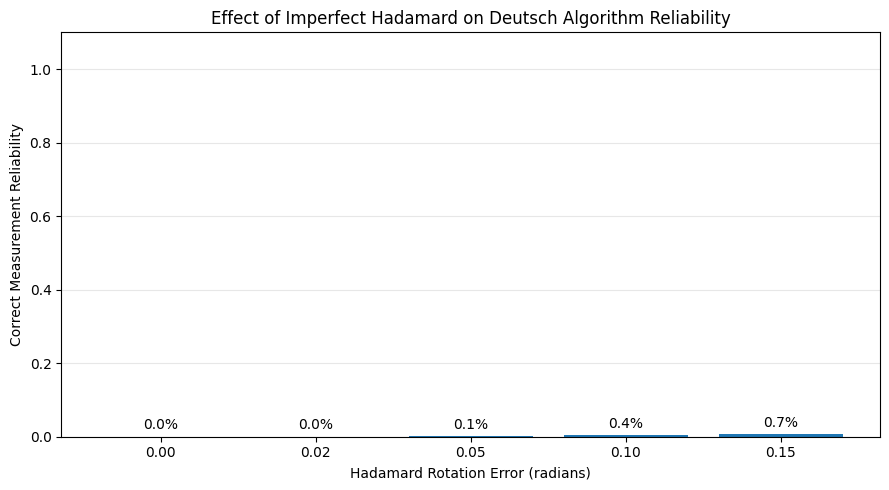

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

SHOTS = 5000

# ---------------------------------------------------------
# IMPERFECT HADAMARD
# ---------------------------------------------------------

def imperfect_h(qc, qubit, error):

    # Ideal H approximately corresponds to RY(pi/2)
    # We deliberately introduce a small rotation error.

    qc.ry(
        np.pi / 2 + error,
        qubit
    )


# ---------------------------------------------------------
# RUN DEUTSCH ALGORITHM
# ---------------------------------------------------------

def run_experiment(error):

    qc = QuantumCircuit(2)

    # Initial state |0>|1>
    qc.x(1)

    # First Hadamards
    imperfect_h(qc, 0, error)
    imperfect_h(qc, 1, error)

    # Balanced oracle f(x)=x
    qc.cx(0, 1)

    # Final Hadamard on control qubit
    imperfect_h(qc, 0, error)

    # Statevector
    state = Statevector.from_instruction(qc)

    probabilities = state.probabilities()

    p0 = 0.0
    p1 = 0.0

    for index, probability in enumerate(probabilities):

        bit = format(index, "02b")
        q0 = bit[-1]

        if q0 == "0":
            p0 += probability
        else:
            p1 += probability

    # Measurement sampling
    rng = np.random.default_rng(42)

    samples = rng.choice(
        [0, 1],
        size=SHOTS,
        p=[p0, p1]
    )

    count_0 = int(np.sum(samples == 0))
    count_1 = int(np.sum(samples == 1))

    return qc, count_0, count_1, p0, p1


# ---------------------------------------------------------
# TEST DIFFERENT ERROR LEVELS
# ---------------------------------------------------------

error_values = [
    0,
    0.02,
    0.05,
    0.10,
    0.15
]

reliabilities = []

print("\nIMPERFECT HADAMARD EXPERIMENT")
print("=" * 70)

for error in error_values:

    qc, count_0, count_1, p0, p1 = run_experiment(
        error
    )

    reliability = count_1 / SHOTS

    reliabilities.append(reliability)

    print(
        f"\nError = {error:.2f} radians"
    )

    print(f"0 count : {count_0}")
    print(f"1 count : {count_1}")

    print(f"P(0) : {count_0 / SHOTS:.4f}")
    print(f"P(1) : {count_1 / SHOTS:.4f}")

    print(
        f"Correct classification reliability : "
        f"{reliability * 100:.2f}%"
    )

# ---------------------------------------------------------
# DISPLAY CIRCUIT WITH ERROR
# ---------------------------------------------------------

qc, _, _, _, _ = run_experiment(0.10)

print("\nEXAMPLE CIRCUIT WITH IMPERFECT HADAMARD")
print("=" * 70)

print(qc.draw())

# ---------------------------------------------------------
# BAR CHART
# ---------------------------------------------------------

error_labels = [
    "0.00",
    "0.02",
    "0.05",
    "0.10",
    "0.15"
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    error_labels,
    reliabilities
)

plt.xlabel("Hadamard Rotation Error (radians)")
plt.ylabel("Correct Measurement Reliability")

plt.title(
    "Effect of Imperfect Hadamard on Deutsch Algorithm Reliability"
)

plt.ylim(0, 1.1)

for bar, value in zip(
    bars,
    reliabilities
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value * 100:.1f}%",
        ha="center"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()